Task 1 - Data Analysis and Preprocessing

1.1: Data Cleaning

In [1]:
# --- Module 1: Imports ---
import sys
import os
import pandas as pd
import numpy as np

# Add project root for src module
PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

# Import task1_data_analysis module
import src.task1_data_analysis as tda

In [2]:
# --- Module 2: Data Cleaning ---

# Load data
credit_df = pd.read_csv('../data/raw/creditcard.csv')

# Clean data
credit_df = tda.clean_creditcard_data(credit_df)

# --- Basic Info ---
print("Initial shape:", credit_df.shape)
print(credit_df.info())
print(credit_df.isnull().sum())

# --- 1. Handle Missing Values ---
if credit_df.isnull().sum().sum() > 0:
    numeric_cols = credit_df.select_dtypes(include=np.number).columns.tolist()
    for col in numeric_cols:
        if credit_df[col].isnull().sum() > 0:
            median_value = credit_df[col].median()
            credit_df[col].fillna(median_value, inplace=True)
            print(f"Filled missing numeric values in {col} with median: {median_value}")

    categorical_cols = credit_df.select_dtypes(include='object').columns.tolist()
    for col in categorical_cols:
        if credit_df[col].isnull().sum() > 0:
            mode_value = credit_df[col].mode()[0]
            credit_df[col].fillna(mode_value, inplace=True)
            print(f"Filled missing categorical values in {col} with mode: {mode_value}")
else:
    print("No missing values found.")

# --- 2. Remove Duplicates ---
duplicates = credit_df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
credit_df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", credit_df.shape)

# --- 3. Correct Data Types ---
credit_df["Class"] = credit_df["Class"].astype(int)
credit_df["Time"] = credit_df["Time"].astype(float)
credit_df["Amount"] = credit_df["Amount"].astype(float)

print("\nData types after correction:")
print(credit_df.dtypes)

print("\n--- Credit Card Data Cleaning Completed ---")


Initial shape: (283726, 31)
<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  

1.2. Exploratory Data Analysis

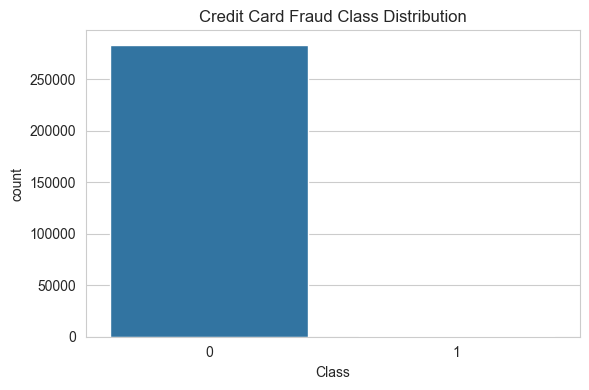

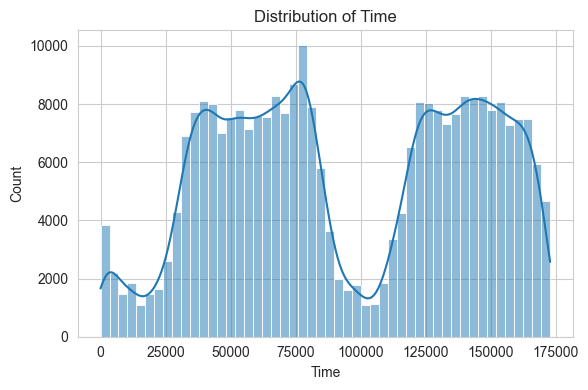

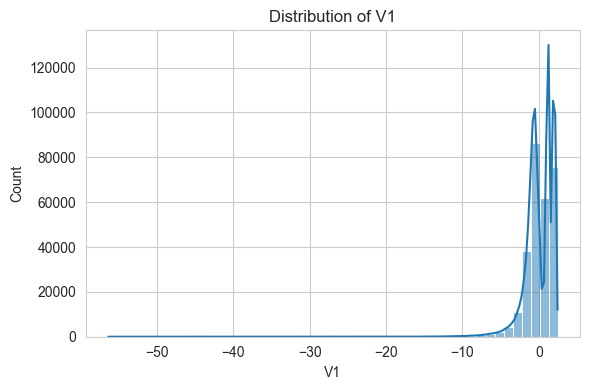

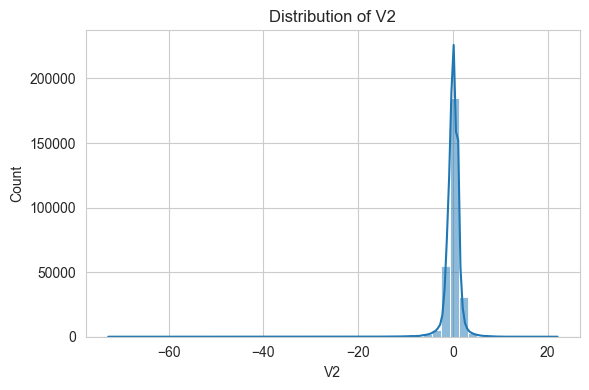

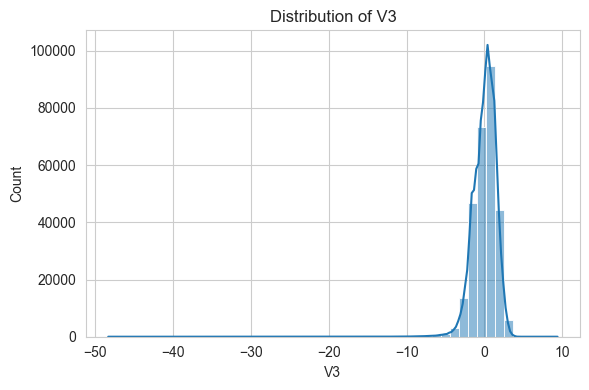

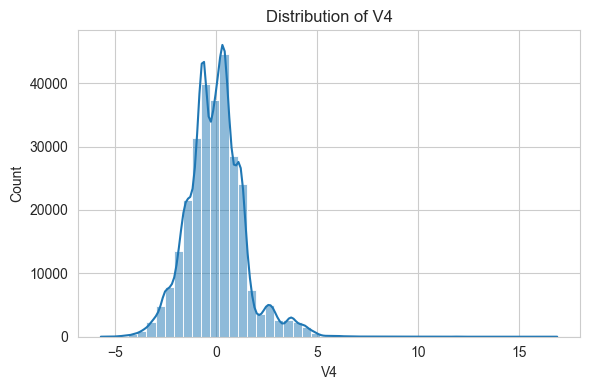

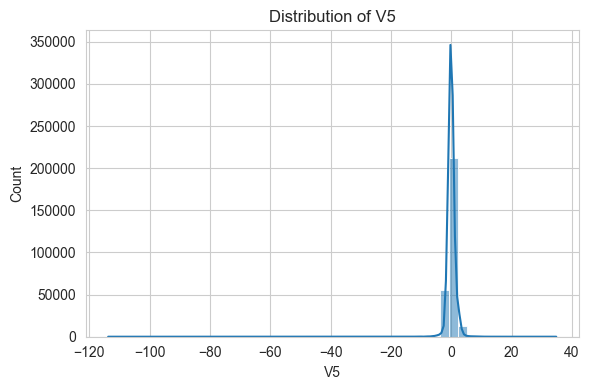

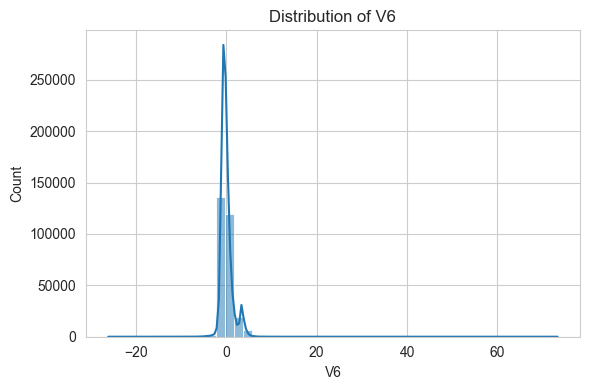

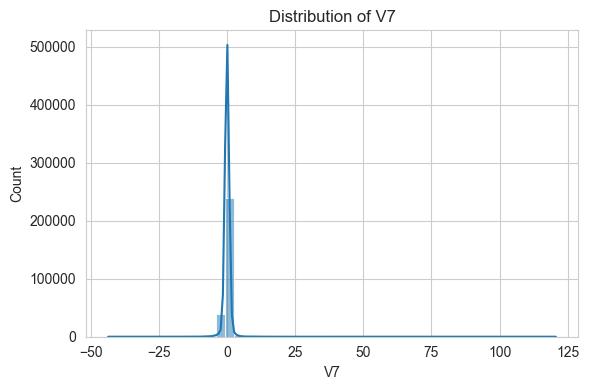

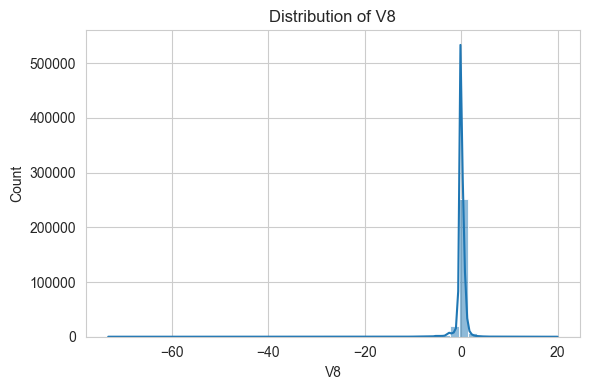

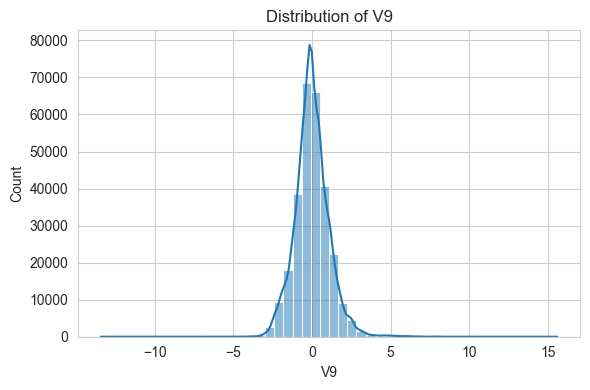

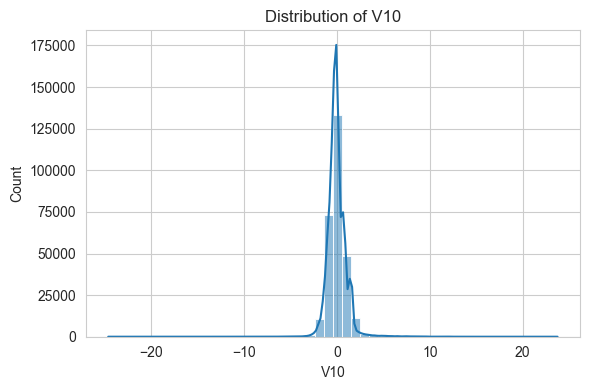

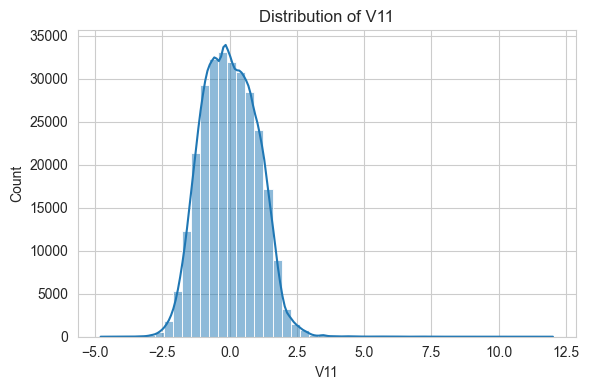

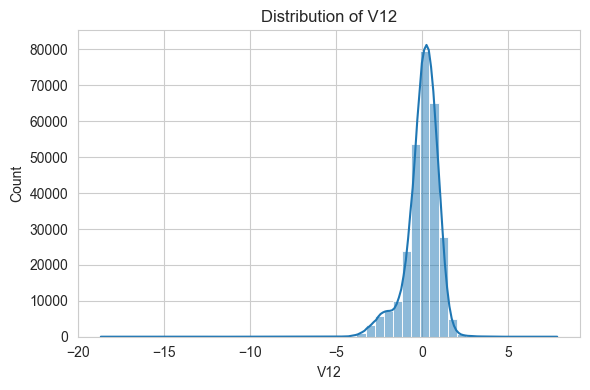

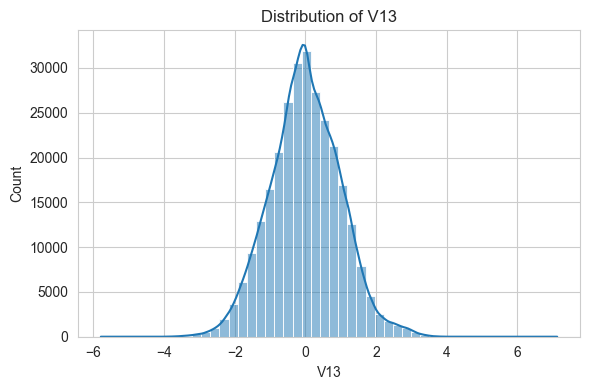

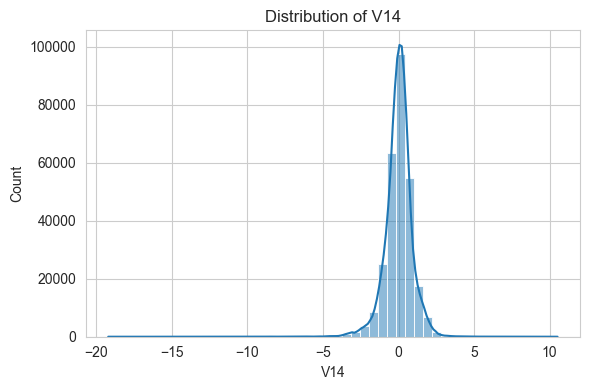

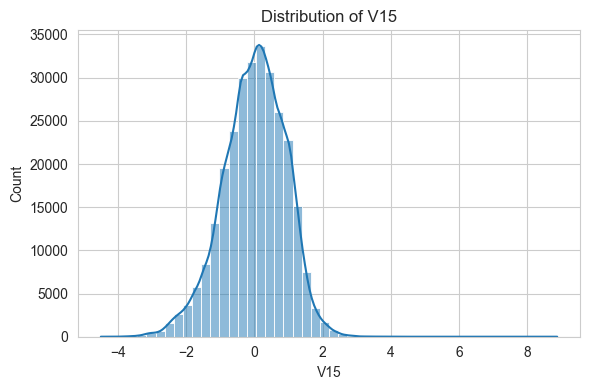

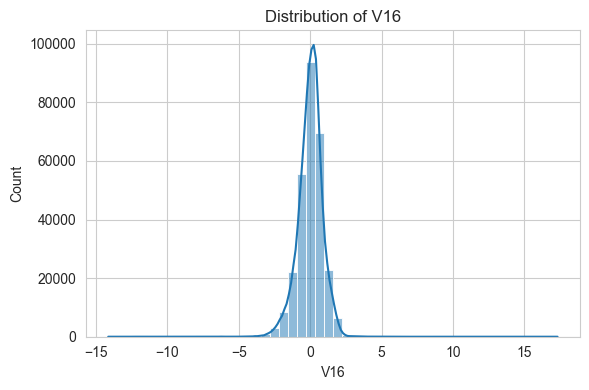

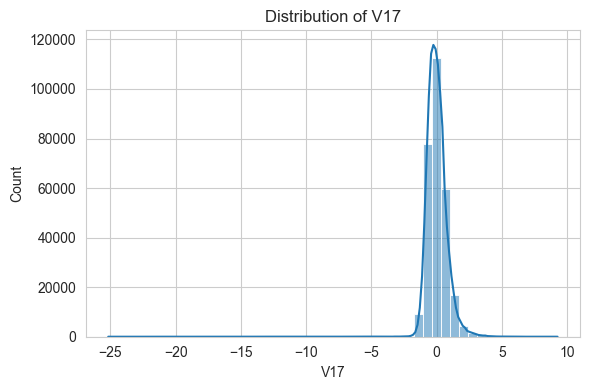

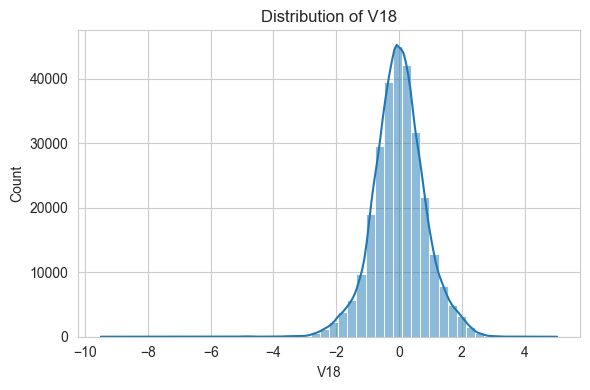

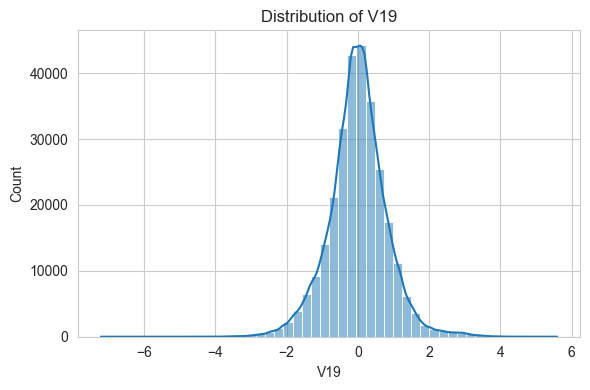

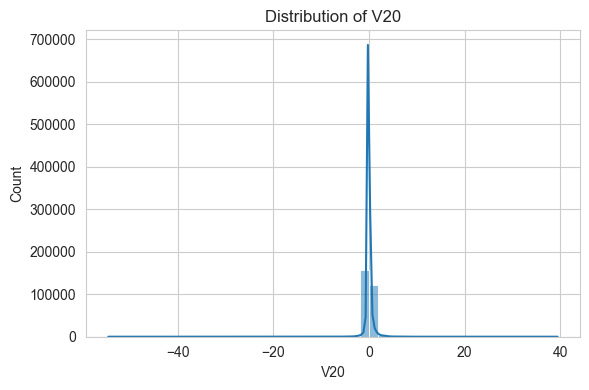

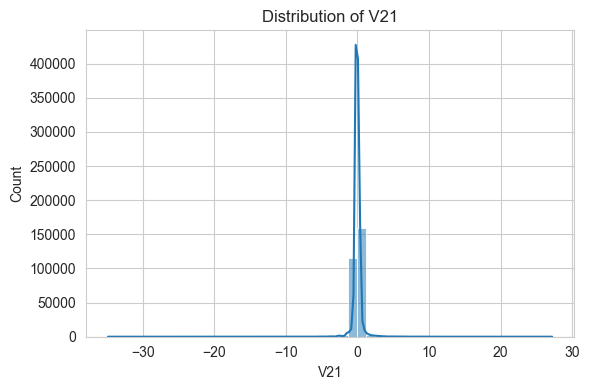

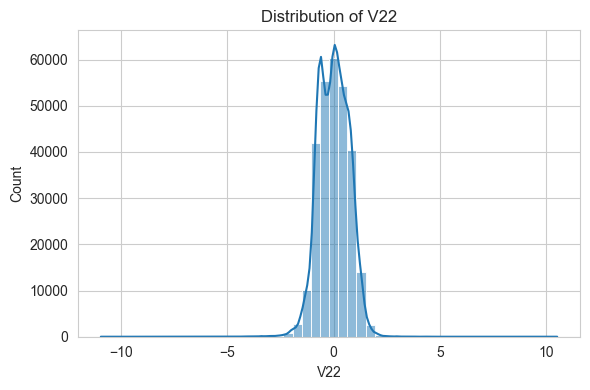

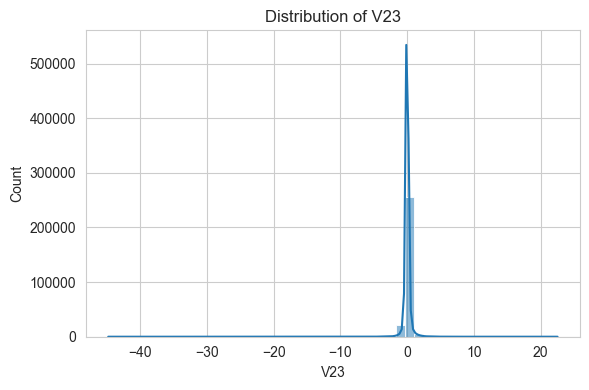

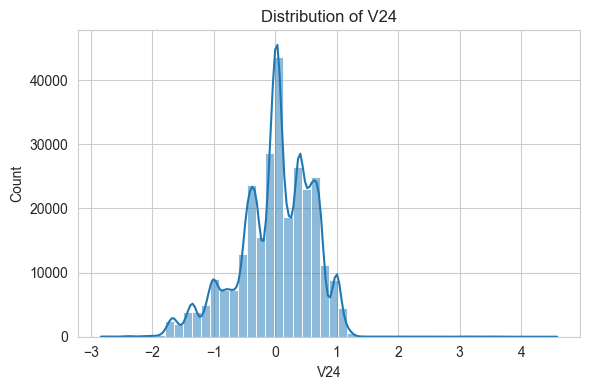

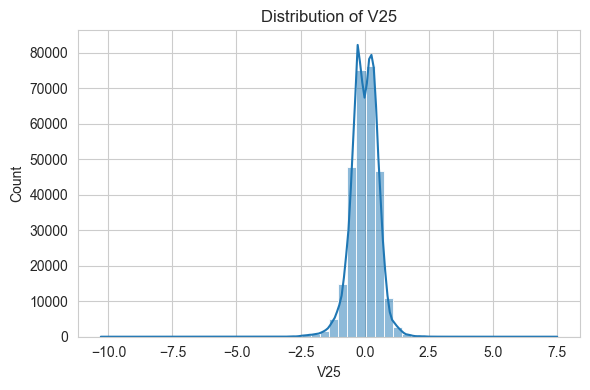

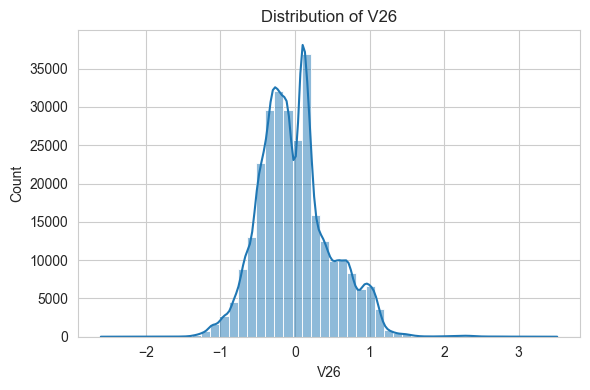

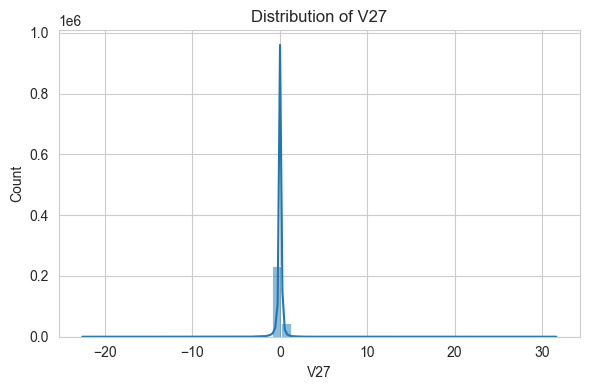

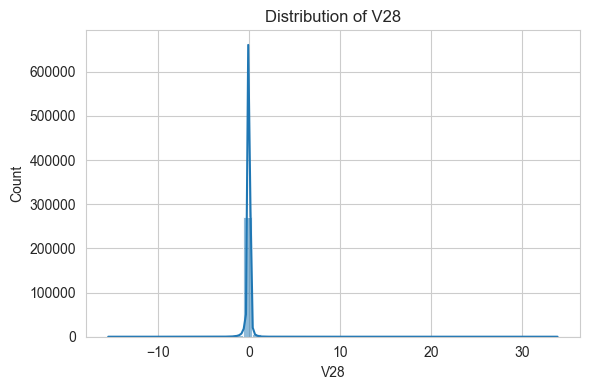

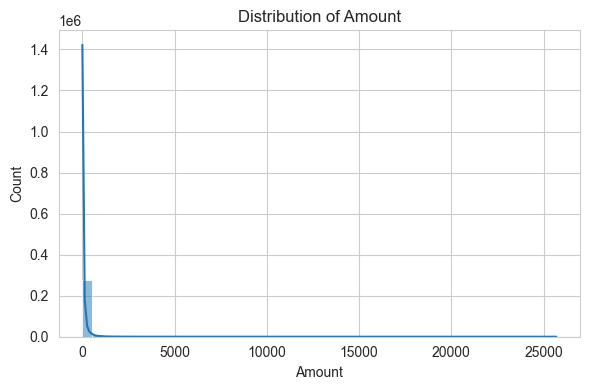

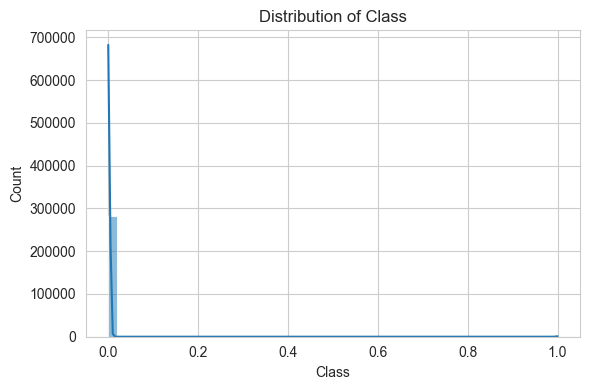

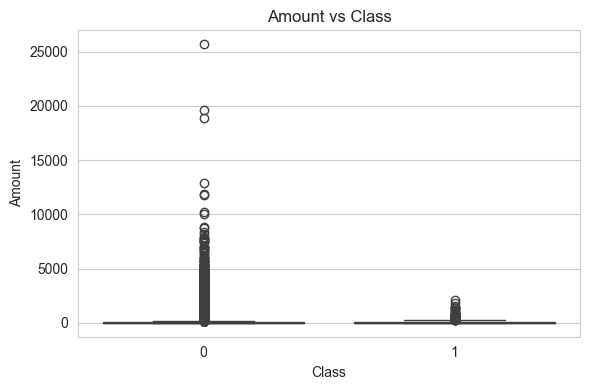

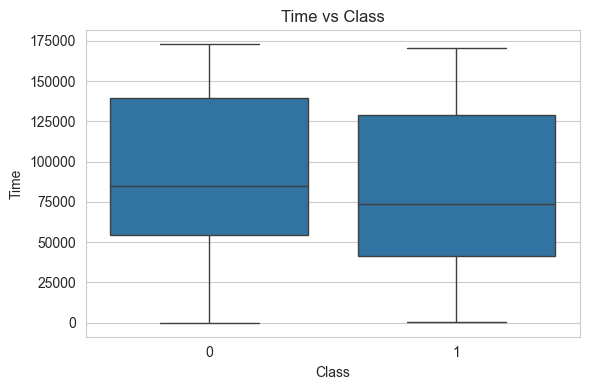

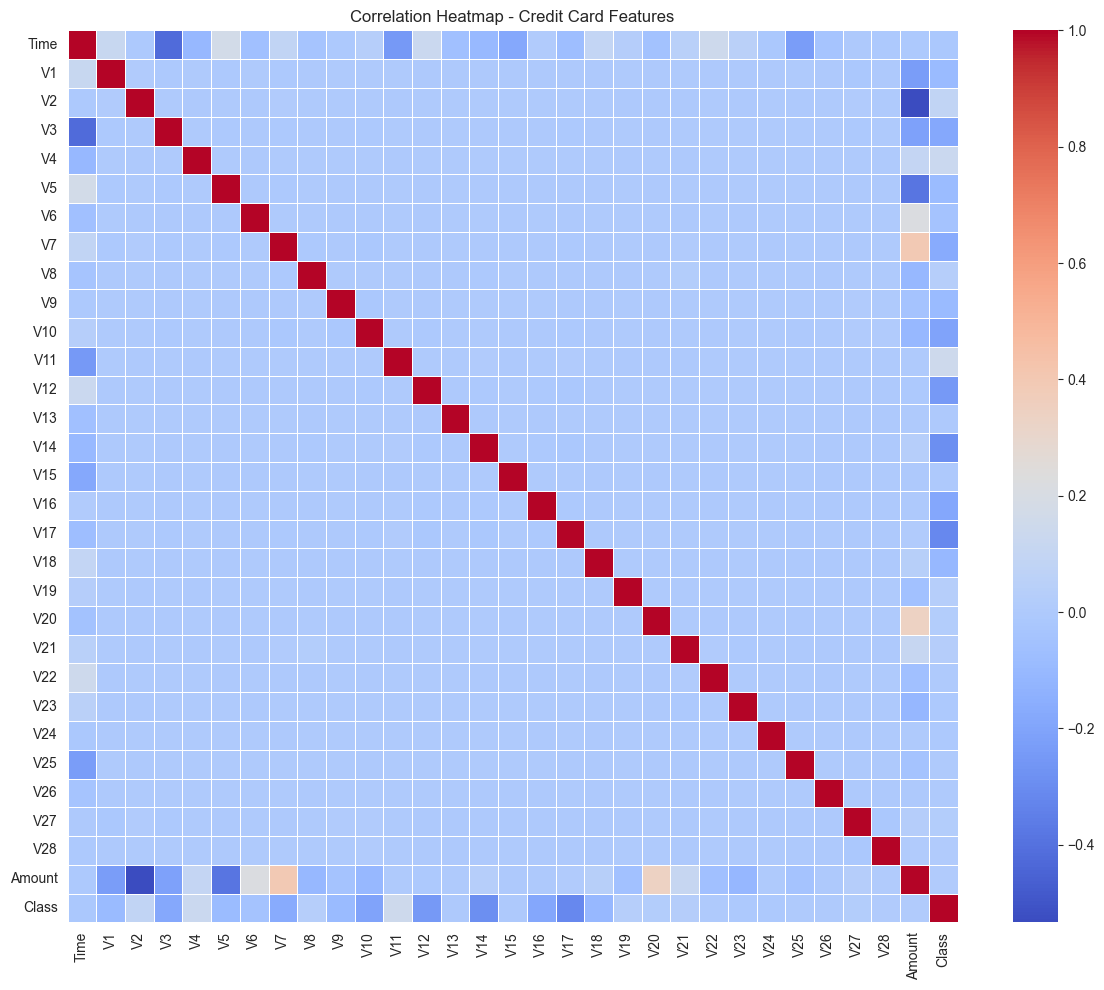

In [3]:
# --------------------------------------------
# Module 2: Exploratory Data Analysis (EDA)
# --------------------------------------------

# 1. Class Distribution Analysis
tda.plot_class_distribution(
    credit_df,
    target_col='Class',
    title='Credit Card Fraud Class Distribution'
)

# 2. Univariate Analysis: numeric features
numeric_cols = credit_df.select_dtypes(include='number').columns.tolist()
tda.univariate_analysis(credit_df, numeric_cols)

# 3. Bivariate Analysis: selected numeric features vs target
bivariate_features = ['Amount', 'Time']  # adjust if needed
for feature in bivariate_features:
    tda.bivariate_analysis(credit_df, feature=feature, target='Class', kind='box')

# 4. Optional: Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(credit_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Credit Card Features')
plt.tight_layout()
plt.show()
